# Preamble

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append('../')
import resonances

# Cavity reflection, asymmetric

In [2]:
data = np.load('2021-10-01 transmon/S21_vs_power.npz')
data.files

['filename', 'f', 'data', 'power', 'N', 'M', 'meta', 'S_parameter']

In [3]:
data['power'], data['S_parameter']

(array([-60., -59., -58., -57., -56., -55., -54., -53., -52., -51., -50.,
        -49., -48., -47., -46., -45., -44., -43., -42., -41., -40., -39.,
        -38., -37., -36., -35., -34., -33., -32., -31., -30.]),
 array('S21', dtype='<U3'))

[[Model]]
    Model(reflection_asym)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 113
    # data points      = 202
    # variables        = 9
    chi-square         = 1.4555e-04
    reduced chi-square = 7.5416e-07
    Akaike info crit   = -2838.93316
    Bayesian info crit = -2809.15875
    R-squared          = 0.99952419
[[Variables]]
    fr:        8.17718173 +/- 4.6938e-06 (0.00%) (init = 8.1771)
    external:  0.00165463 +/- 1.32934416 (80340.78%) (init = 0.001)
    internal:  2.8208e-04 +/- 1.32934613 (471271.42%) (init = 0.001)
    A:        -0.07251009 +/- 70.8346162 (97689.32%) (init = 0.06)
    b:         0.16232072 +/- 145.326970 (89530.76%) (init = 0.1)
    phi:       1.10228182 +/- 3699.31570 (335605.25%) (init = 0)
    theta:    -0.37760958 +/- 0.00428687 (1.14%) (init = 0)
    delay:    -9.58564279 +/- 0.57161881 (5.96%) (init = 0)
    Aslope:    3.24787650 +/- 0.51336076 (15.81%) (init = 0)
[[Correlations]] (unreported correlations are < 0

Text(0.5, 0, 'f / GHz')

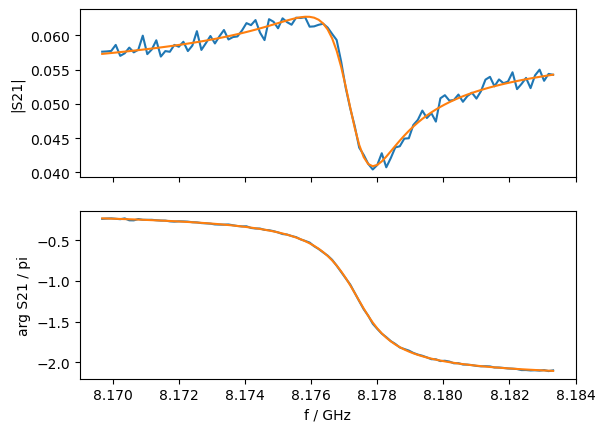

In [4]:
f = data['f'] / 1e9 # GHz
S = data['data']
pidx = 5

model = resonances.make_asym_reflection_model()
res = model.fit(S[pidx].view(float), f=f, fr=8.1771, external=1e-3, internal=1e-3, A=0.06, phi=0, b=0.1, theta=0)
print(res.fit_report())

fig, axs = plt.subplots(nrows=2, sharex=True)
axs[0].plot(f, np.abs(S[pidx]))
axs[1].plot(f, np.unwrap(np.angle(S[pidx]))/np.pi)
axs[0].plot(f, np.abs(res.best_fit.view(complex)))
axs[1].plot(f, np.unwrap(np.angle(res.best_fit.view(complex)))/np.pi)
axs[0].set_ylabel('|S21|')
axs[1].set_ylabel('arg S21 / pi')
axs[1].set_xlabel('f / GHz')

# Hanger

## data set 1

In [5]:
data = np.load('2022-12-24 pinhole spectroscopy hanger/2022-12-24_13-57-05_6Ghz_vs_power.npz')
data.files

['f', 'S21', 'S11', 'power', 'if_bw', 'meta']

**Transmission**

[[Model]]
    Model(hanger_transmission_asym)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 403
    # data points      = 2002
    # variables        = 8
    chi-square         = 0.00132044
    reduced chi-square = 6.6220e-07
    Akaike info crit   = -28475.8530
    Bayesian info crit = -28431.0378
    R-squared          = 0.99923805
[[Variables]]
    fr:        5.96144098 +/- 9.5589e-07 (0.00%) (init = 5.96)
    external:  8.6846e-05 +/- 5.3267e-07 (0.61%) (init = 0.001)
    internal:  7.5699e-05 +/- 1.3247e-06 (1.75%) (init = 0.001)
    phi:      -6.44943583 +/- 0.00715147 (0.11%) (init = 0)
    A:         0.04390257 +/- 3.0877e-05 (0.07%) (init = 0.05)
    theta:     2.23896503 +/- 7.1381e-04 (0.03%) (init = 0.7)
    delay:     0.04271252 +/- 1.21042388 (2833.89%) (init = 0)
    Aslope:    1.74924576 +/- 1.22791664 (70.20%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(fr, phi)            = -0.8782
    C(fr, internal)       = -

Text(0.5, 0, 'f / GHz')

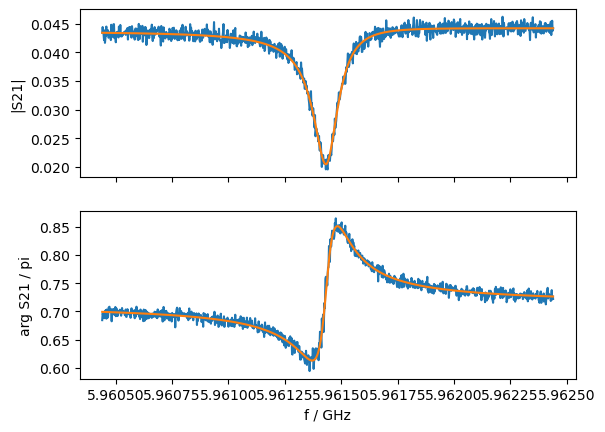

In [6]:
f = data['f'] / 1e9
S = data['S21']
pidx = 0

model = resonances.make_asym_hanger_transmission_model()
res = model.fit(data['S21'][pidx].view(float), f=f, fr=5.96, external=1e-3, internal=1e-3, A=0.05, phi=0, theta=0.7)
print(res.fit_report())

fig, axs = plt.subplots(nrows=2, sharex=True)
axs[0].plot(f, np.abs(S[pidx]))
axs[1].plot(f, np.unwrap(np.angle(S[pidx]))/np.pi)
axs[0].plot(f, np.abs(res.best_fit.view(complex)))
axs[1].plot(f, np.unwrap(np.angle(res.best_fit.view(complex)))/np.pi)
axs[0].set_ylabel('|S21|')
axs[1].set_ylabel('arg S21 / pi')
axs[1].set_xlabel('f / GHz')

**Reflection**

[[Model]]
    Model(hanger_reflection_asym)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 188
    # data points      = 2002
    # variables        = 7
    chi-square         = 1.2682e-05
    reduced chi-square = 6.3570e-09
    Akaike info crit   = -37778.1776
    Bayesian info crit = -37738.9643
    R-squared          = 0.99940981
[[Variables]]
    fr:      5.96144130 +/- 1.3197e-07 (0.00%) (init = 5.9615)
    width:   1.4497e-04 +/- 2.5210e-07 (0.17%) (init = 0.0002)
    A:       0.01958619 +/- 1.7342e-05 (0.09%) (init = 0.01)
    b:       0.24163835 +/- 2.5035e-04 (0.10%) (init = 0.1)
    phi:    -3.08443843 +/- 8.8383e-04 (0.03%) (init = 3.141593)
    theta:   3.73234921 +/- 0.00102486 (0.03%) (init = 1)
    delay:   0.62973116 +/- 1.07036683 (169.97%) (init = 0)
    Aslope:  0 (fixed)
[[Correlations]] (unreported correlations are < 0.100)
    C(fr, theta)    = -0.8465
    C(width, b)     = +0.8374
    C(A, b)         = -0.8096
    C(phi, theta)   = -0

Text(0.5, 0, 'f / GHz')

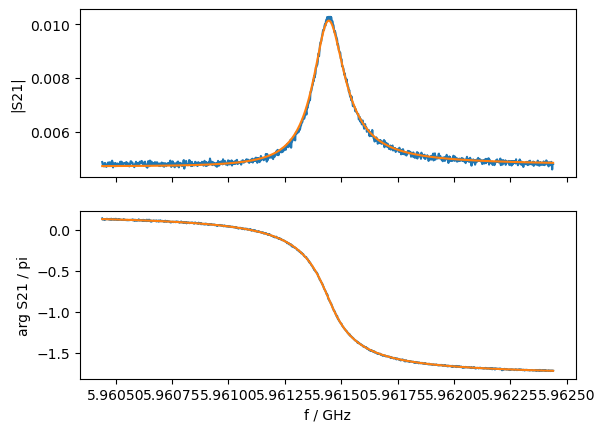

In [7]:
f = data['f'] / 1e9
S = data['S11']
pidx = 2

model = resonances.make_asym_hanger_reflection_model()
model.set_param_hint('Aslope', vary=False)
#model.set_param_hint('delay', vary=False)
res = model.fit(S[pidx].view(float), f=f, fr=5.9615, width=2e-4, A=0.01, b=0.1, phi=np.pi, theta=1)
print(res.fit_report())

fig, axs = plt.subplots(nrows=2, sharex=True)
axs[0].plot(f, np.abs(S[pidx]))
axs[1].plot(f, np.unwrap(np.angle(S[pidx]))/np.pi)
axs[0].plot(f, np.abs(res.best_fit.view(complex)))
axs[1].plot(f, np.unwrap(np.angle(res.best_fit.view(complex)))/np.pi)
axs[0].set_ylabel('|S21|')
axs[1].set_ylabel('arg S21 / pi')
axs[1].set_xlabel('f / GHz')

## data set 2

In [8]:
data = np.load('2022-12-24 pinhole spectroscopy hanger/2022-12-24_14-25-46_9Ghz_vs_power.npz')
data.files

['f', 'S21', 'S11', 'power', 'if_bw', 'meta']

In [9]:
data['power']

array([-60., -50., -40., -30., -20., -10.,   0.,  10.])

**Transmission**

[[Model]]
    Model(hanger_transmission_asym)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 301
    # data points      = 2002
    # variables        = 8
    chi-square         = 0.00118208
    reduced chi-square = 5.9282e-07
    Akaike info crit   = -28697.4504
    Bayesian info crit = -28652.6352
    R-squared          = 0.99799014
[[Variables]]
    fr:        8.99765670 +/- 2.3584e-06 (0.00%) (init = 8.9977)
    external:  1.7999e-04 +/- 1.7045e-06 (0.95%) (init = 0.001)
    internal:  1.8974e-04 +/- 3.7903e-06 (2.00%) (init = 0.001)
    phi:       0.42263062 +/- 0.01019699 (2.41%) (init = 0)
    A:         0.02784801 +/- 3.5300e-05 (0.13%) (init = 0.05)
    theta:     2.72426970 +/- 0.00151087 (0.06%) (init = 0.7)
    delay:    -0.47116238 +/- 2.09193412 (443.99%) (init = 0)
    Aslope:    0.81592357 +/- 2.31562768 (283.80%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(fr, phi)            = -0.9106
    C(fr, internal)       =

Text(0.5, 0, 'f / GHz')

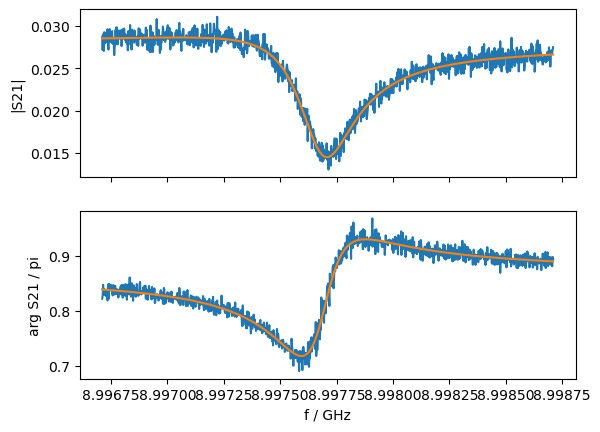

In [10]:
f = data['f'] / 1e9
S = data['S21']
pidx = 0

model = resonances.make_asym_hanger_transmission_model()
res = model.fit(data['S21'][pidx].view(float), f=f, fr=8.9977, external=1e-3, internal=1e-3, A=0.05, phi=0, theta=0.7)
print(res.fit_report())

fig, axs = plt.subplots(nrows=2, sharex=True)
axs[0].plot(f, np.abs(S[pidx]))
axs[1].plot(f, np.unwrap(np.angle(S[pidx]))/np.pi)
axs[0].plot(f, np.abs(res.best_fit.view(complex)))
axs[1].plot(f, np.unwrap(np.angle(res.best_fit.view(complex)))/np.pi)
axs[0].set_ylabel('|S21|')
axs[1].set_ylabel('arg S21 / pi')
axs[1].set_xlabel('f / GHz')

**Reflection**

[[Model]]
    Model(hanger_reflection_asym)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 193
    # data points      = 2002
    # variables        = 6
    chi-square         = 7.8320e-06
    reduced chi-square = 3.9239e-09
    Akaike info crit   = -38745.1051
    Bayesian info crit = -38711.4937
    R-squared          = 0.99776385
[[Variables]]
    fr:      8.99766036 +/- 5.9141e-07 (0.00%) (init = 8.9977)
    width:   3.3973e-04 +/- 1.1356e-06 (0.33%) (init = 0.0002)
    A:      -0.00557640 +/- 6.7457e-06 (0.12%) (init = 0.01)
    b:       0.36166071 +/- 6.4770e-04 (0.18%) (init = 0.1)
    phi:    -1.98064307 +/- 0.00272076 (0.14%) (init = 0)
    theta:   1.71258711 +/- 0.00257797 (0.15%) (init = 1)
    delay:   0 (fixed)
    Aslope:  0 (fixed)
[[Correlations]] (unreported correlations are < 0.100)
    C(phi, theta)   = -0.8851
    C(fr, theta)    = -0.8621
    C(fr, phi)      = +0.7885
    C(width, b)     = +0.7463
    C(fr, b)        = -0.7439
    C(b,

Text(0.5, 0, 'f / GHz')

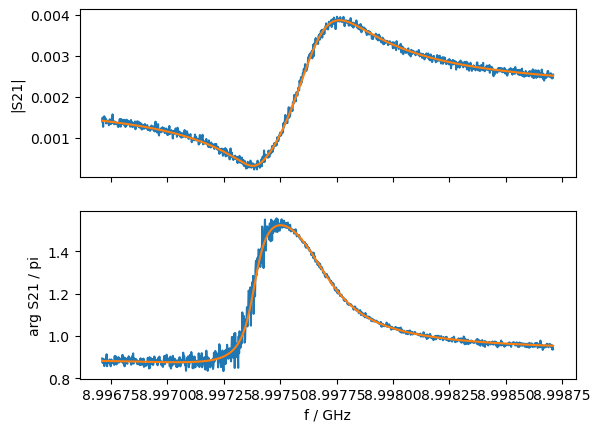

In [11]:
f = data['f'] / 1e9
S = data['S11']
pidx = 2

model = resonances.make_asym_hanger_reflection_model()
model.set_param_hint('Aslope', vary=False)
model.set_param_hint('delay', vary=False)
res = model.fit(S[pidx].view(float), f=f, fr=8.9977, width=2e-4, A=0.01, b=0.1, phi=0, theta=1)
print(res.fit_report())

fig, axs = plt.subplots(nrows=2, sharex=True)
axs[0].plot(f, np.abs(S[pidx]))
axs[1].plot(f, np.unwrap(np.angle(S[pidx]))/np.pi)
axs[0].plot(f, np.abs(res.best_fit.view(complex)))
axs[1].plot(f, np.unwrap(np.angle(res.best_fit.view(complex)))/np.pi)
axs[0].set_ylabel('|S21|')
axs[1].set_ylabel('arg S21 / pi')
axs[1].set_xlabel('f / GHz')